In [2]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#loading data 
df=pd.read_csv('netflix_titles.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [5]:
#data cleaning
#removing null function
df.dropna()
#spliting country
df["country"]=df["country"].str.strip()
df["country"]=df["country"].str.split(",")
df=df.explode("country")
df["country"]=df["country"].str.strip()



In [6]:
#content type description
df.groupby("type").size()

type
Movie      7819
TV Show    3031
dtype: int64

In [7]:
#popular country
df.groupby("country").size().sort_values(ascending=False).head(10)

country
United States     3690
India             1046
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
dtype: int64

In [8]:
#dates with most releases
df["release_year"].value_counts().sort_values(ascending=False).head(10)

release_year
2018    1392
2017    1276
2019    1208
2016    1155
2020    1055
2015     728
2021     658
2014     481
2013     366
2012     302
Name: count, dtype: int64

In [9]:
#when did netflix added most content
df["date_added"]=pd.to_datetime(df["date_added"], format="mixed")
df["date_added"].dt.year.value_counts().sort_values(ascending=False).head(20)

date_added
2019.0    2421
2020.0    2337
2018.0    2039
2021.0    1831
2017.0    1474
2016.0     558
2015.0     106
2014.0      35
2011.0      17
2013.0      13
2012.0       4
2009.0       2
2008.0       2
2010.0       1
Name: count, dtype: int64

In [10]:
#most popular genre
df["listed_in"].str.split(",").explode().str.strip().value_counts().head(10)

listed_in
International Movies        3513
Dramas                      3202
Comedies                    1981
International TV Shows      1465
Action & Adventure          1182
Documentaries               1118
Independent Movies          1040
TV Dramas                    852
Children & Family Movies     845
Thrillers                    806
Name: count, dtype: int64

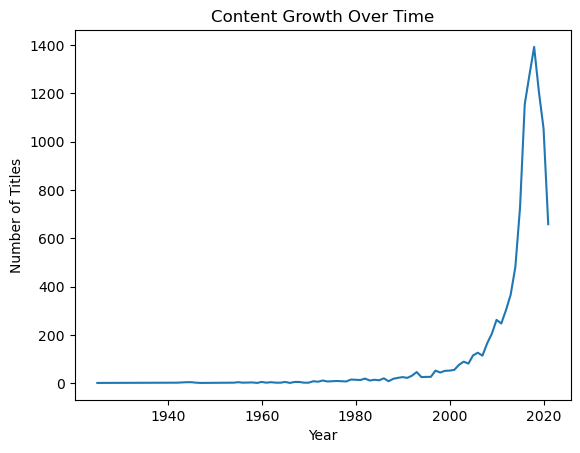

In [11]:
#content growth over time
df["release_year"].value_counts().sort_index().plot(kind="line")
plt.title("Content Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.show()

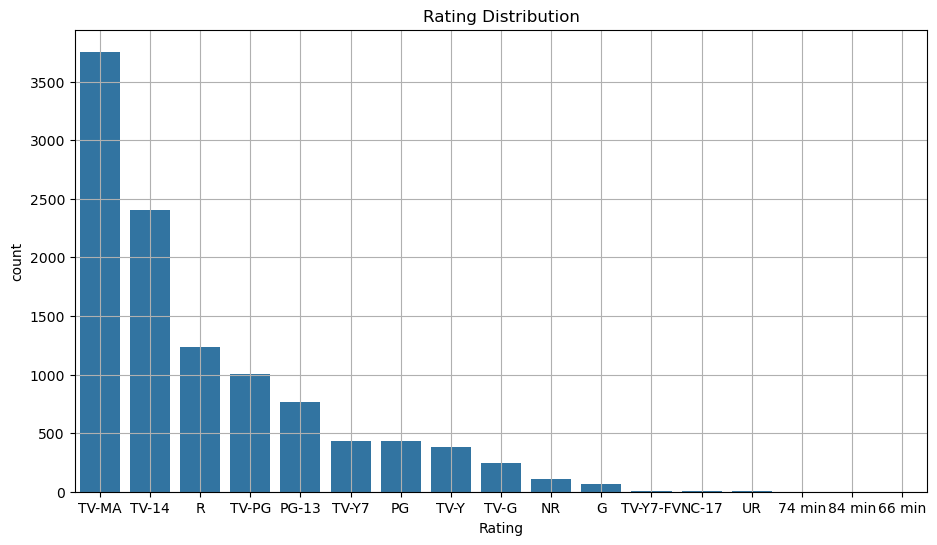

In [19]:

# Rating distribution
df_clean = df.dropna(subset=["rating"]).reset_index(drop=True)  
plt.figure(figsize=(11, 6))
sns.countplot(x="rating", data=df_clean, order=df_clean["rating"].value_counts().index)
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.grid()
plt.show()

In [23]:
#top ten directors
df["director"].str.split(",").explode().str.strip().value_counts().head(10)


director
Rajiv Chilaka       22
Jan Suter           21
Raúl Campos         19
Steven Spielberg    18
Martin Scorsese     18
Youssef Chahine     17
Suhas Kadav         16
Marcus Raboy        16
Martin Campbell     15
Don Michael Paul    15
Name: count, dtype: int64

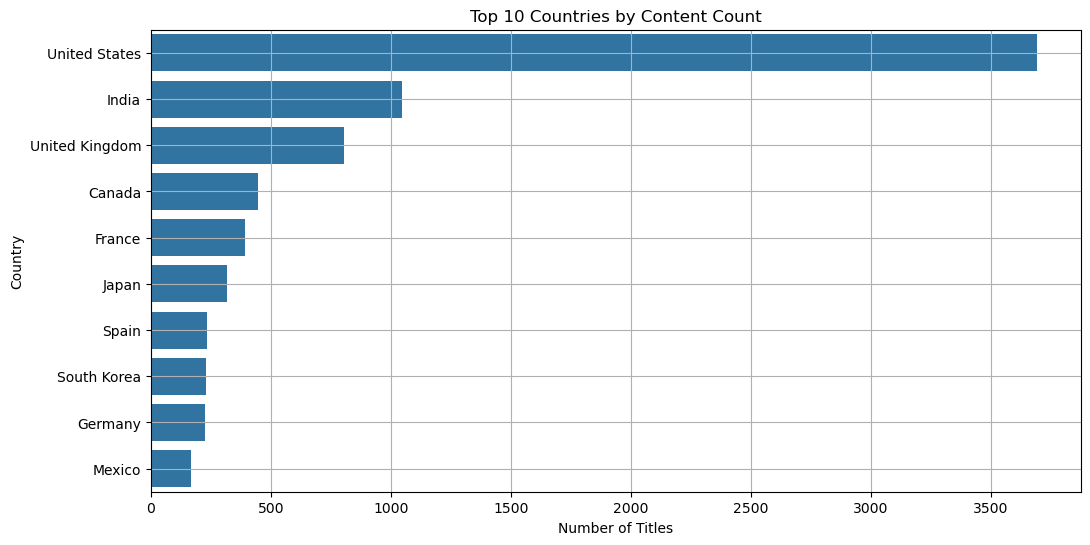

In [27]:
#country wise content distribution
plt.figure(figsize=(12, 6))
df_clean = df.dropna(subset=["country"]).reset_index(drop=True)
sns.countplot(y="country", data=df_clean, order=df_clean["country"].value_counts().head(10).index)
plt.title("Top 10 Countries by Content Count")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.grid()
plt.show()